Mustafa Sefa Soysal // 23050111037

# 3 – Model Testing
Loads the trained model from Google Drive and evaluates on the test set. Computes metrics and generates visualisations.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pycocotools segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.2 MB/s eta 0:00:00


## Step 1: Setup – Copy COCO to Local Storage

In [3]:
import os
import shutil

# --- Configuration: UPDATE THESE PATHS ---
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'
local_coco_path = '/content/coco_dataset_local'

# Create the local directory if it doesn't exist
os.makedirs(local_coco_path, exist_ok=True)

print(f"Setting up COCO data in fast local Colab storage ('{local_coco_path}')...")

# --- 1. Copy Annotations ---
drive_annotations_src = os.path.join(drive_coco_path, 'annotations')
local_annotations_dst = os.path.join(local_coco_path, 'annotations')

if os.path.exists(drive_annotations_src) and not os.path.exists(local_annotations_dst):
    print(f"  Copying annotations...")
    try:
        shutil.copytree(drive_annotations_src, local_annotations_dst, dirs_exist_ok=True)
    except OSError as e:
        print(f"\n⚠️ GOOGLE DRIVE BAĞLANTISI KOPTU! (Transport endpoint error)\nLütfen üstteki drive.mount hücresini tekrar çalıştırın veya çalışma zamanını yeniden başlatın.\nHata detayı: {e}")
    print("  Annotations copied successfully.")
elif os.path.exists(local_annotations_dst):
    print("  Annotations already exist in local storage. Skipping copy.")

# --- 2. FAST IMAGE EXTRACTION: Unzip directly to local disk ---
# Instead of copying 100k loose files from Drive (which takes hours),
# we unzip the zip file stored in Drive directly to the fast local SSD.
local_img_dir = os.path.join(local_coco_path, 'images')
os.makedirs(local_img_dir, exist_ok=True)

train_zip = os.path.join(drive_coco_path, 'train2017.zip')
val_zip = os.path.join(drive_coco_path, 'val2017.zip')

print("\n--- Extracting Images to Local Disk ---")
if not os.path.exists(os.path.join(local_img_dir, 'train2017')):
    if os.path.exists(train_zip):
        print("  Unzipping train2017.zip directly to local storage (this is fast)...")
        !unzip -q "{train_zip}" -d "{local_img_dir}"
    else:
        print(f"  Warning: {train_zip} not found in Drive. Ensure it was downloaded in Step 3.")
else:
    print("  train2017 images already exist locally.")

if not os.path.exists(os.path.join(local_img_dir, 'val2017')):
    if os.path.exists(val_zip):
        print("  Unzipping val2017.zip directly to local storage...")
        !unzip -q "{val_zip}" -d "{local_img_dir}"
    else:
        print(f"  Warning: {val_zip} not found in Drive. Ensure it was downloaded in Step 3.")
else:
    print("  val2017 images already exist locally.")

print("\nCOCO data setup for local access complete! Your GPU will no longer be bottlenecked by Drive I/O.")

Setting up COCO data in fast local Colab storage ('/content/coco_dataset_local')...
  Copying annotations...
  Annotations copied successfully.

--- Extracting Images to Local Disk ---
  Unzipping train2017.zip directly to local storage (this is fast)...
  Unzipping val2017.zip directly to local storage...

COCO data setup for local access complete! Your GPU will no longer be bottlenecked by Drive I/O.


## Step 2: Load Annotations and Image Paths

In [4]:
import os
from pycocotools.coco import COCO

# --- Robust Path Resolution ---
local_coco_path = '/content/coco_dataset_local'
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

# Handle nested annotations dynamically (Local first, then Drive)
base_ann_local = os.path.join(local_coco_path, 'annotations')
base_ann_drive = os.path.join(drive_coco_path, 'annotations')

if os.path.exists(os.path.join(base_ann_local, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_ann_local, 'annotations')
elif os.path.exists(os.path.join(base_ann_local, 'instances_train2017.json')):
    annotations_dir = base_ann_local
elif os.path.exists(os.path.join(base_ann_drive, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_ann_drive, 'annotations')
else:
    annotations_dir = base_ann_drive

annotation_filename = 'instances_train2017.json'
annotation_file = os.path.join(annotations_dir, annotation_filename)

print(f"Using annotation directory: {annotations_dir}")

if not os.path.exists(annotation_file):
    print(f"Error: Annotation file not found at {annotation_file}")
else:
    print(f"Successfully found annotation file: {annotation_file}")
    coco = COCO(annotation_file)
    print("\n--- COCO Dataset Information ---")
    cats = coco.loadCats(coco.getCatIds())
    print('COCO categories: %s' % ', '.join([cat['name'] for cat in cats]))
    print(f"Total images: {len(coco.getImgIds())}")

Using annotation directory: /content/coco_dataset_local/annotations/annotations
Successfully found annotation file: /content/coco_dataset_local/annotations/annotations/instances_train2017.json
loading annotations into memory...
Done (t=14.10s)
creating index...
index created!

--- COCO Dataset Information ---
COCO categories: person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe, backpack, umbrella, handbag, tie, suitcase, frisbee, skis, snowboard, sports ball, kite, baseball bat, baseball glove, skateboard, surfboard, tennis racket, bottle, wine glass, cup, fork, knife, spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake, chair, couch, potted plant, bed, dining table, toilet, tv, laptop, mouse, remote, keyboard, cell phone, microwave, oven, toaster, sink, refrigerator, book, clock, vase, scissors, teddy b

In [5]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor
import os

# Path to the local COCO dataset root
local_coco_path = '/content/coco_dataset_local'

# Because you commented out the image copy step earlier (to save time),
# the images are likely still in your Google Drive.
# We will dynamically check local first, then fallback to Drive.
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

local_img_dir = os.path.join(local_coco_path, 'images', 'train2017')
drive_img_dir = os.path.join(drive_coco_path, 'images', 'train2017')

if os.path.exists(local_img_dir):
    image_root_dir = local_img_dir
    print(f"Using local image directory: {image_root_dir}")
else:
    image_root_dir = drive_img_dir
    print(f"Using Google Drive image directory: {image_root_dir}")

# Handle the nested annotations directory again
base_annotations_dir = os.path.join(local_coco_path, 'annotations')
if os.path.exists(os.path.join(base_annotations_dir, 'annotations', 'instances_train2017.json')):
    annotations_dir = os.path.join(base_annotations_dir, 'annotations')
else:
    annotations_dir = base_annotations_dir

annotation_file_path = os.path.join(annotations_dir, 'instances_train2017.json')

# --- Verify paths before creating dataset ---
if not os.path.exists(image_root_dir):
    print(f"Error: Image root directory not found: {image_root_dir}")
elif not os.path.exists(annotation_file_path):
    print(f"Error: Annotation file not found: {annotation_file_path}")
else:
    print(f"Image root directory found: {image_root_dir}")
    print(f"Annotation file found: {annotation_file_path}")

    # Create the CocoDetection dataset
    dataset = CocoDetection(
        root=image_root_dir,
        annFile=annotation_file_path
    )

    print(f"\nSuccessfully loaded COCO dataset with {len(dataset)} items.")

    # Example: Access an item
    if len(dataset) > 0:
        img, target = dataset[0]
        print(f"\nFirst image type: {type(img)}")
        print(f"First image size: {img.size}")
    else:
        print("Dataset is empty.")

Using local image directory: /content/coco_dataset_local/images/train2017
Image root directory found: /content/coco_dataset_local/images/train2017
Annotation file found: /content/coco_dataset_local/annotations/annotations/instances_train2017.json
loading annotations into memory...
Done (t=11.90s)
creating index...
index created!

Successfully loaded COCO dataset with 118287 items.

First image type: <class 'PIL.Image.Image'>
First image size: (640, 480)


## Step 3: Fixed Split + Seed Function

In [6]:
import os
import hashlib
import copy
import torchvision
from torchvision.datasets import CocoDetection

# --- 1. Deterministic Seed Generation ---
GLOBAL_SEED = 2025

def make_seed(split_name, image_id, global_seed=GLOBAL_SEED):
    key = f"{split_name}_{image_id}_{global_seed}".encode("utf-8")
    return int(hashlib.sha256(key).hexdigest()[:8], 16)

# --- 2. Dynamic Paths (Local first, then Drive) ---
local_coco_path = '/content/coco_dataset_local'
drive_coco_path = '/content/drive/MyDrive/Neural_Practice_Exam/COCO'

def get_img_dir(split):
    local_dir = os.path.join(local_coco_path, 'images', split)
    drive_dir = os.path.join(drive_coco_path, 'images', split)
    return local_dir if os.path.exists(local_dir) else drive_dir

train_img_dir = get_img_dir('train2017')
val_img_dir = get_img_dir('val2017')

base_ann_local = os.path.join(local_coco_path, 'annotations')
base_ann_drive = os.path.join(drive_coco_path, 'annotations')

if os.path.exists(os.path.join(base_ann_local, 'annotations', 'instances_train2017.json')):
    ann_dir = os.path.join(base_ann_local, 'annotations')
elif os.path.exists(os.path.join(base_ann_local, 'instances_train2017.json')):
    ann_dir = base_ann_local
elif os.path.exists(os.path.join(base_ann_drive, 'annotations', 'instances_train2017.json')):
    ann_dir = os.path.join(base_ann_drive, 'annotations')
else:
    ann_dir = base_ann_drive

train_ann_file = os.path.join(ann_dir, 'instances_train2017.json')
val_ann_file = os.path.join(ann_dir, 'instances_val2017.json')

print(f"Using Train Images: {train_img_dir}")
print(f"Using Val Images: {val_img_dir}")
print(f"Using Annotations: {ann_dir}\n")

print("Loading annotations (this may take a moment)...")
try:
    # Initialize full datasets
    train_dataset_full = CocoDetection(root=train_img_dir, annFile=train_ann_file)
    val_dataset_full = CocoDetection(root=val_img_dir, annFile=val_ann_file)

    # --- 3. Sort COCO image IDs in increasing order ---
    train_dataset_full.ids = sorted(train_dataset_full.ids)
    val_dataset_full.ids = sorted(val_dataset_full.ids)

    # --- 4, 5, 6. Create the subsets by slicing the IDs ---
    train_dataset = copy.copy(train_dataset_full)
    train_dataset.ids = train_dataset_full.ids[:5000]

    val_dataset = copy.copy(val_dataset_full)
    val_dataset.ids = val_dataset_full.ids[:1000]

    test_dataset = copy.copy(val_dataset_full)
    test_dataset.ids = val_dataset_full.ids[1000:2000]

    print("\n--- Dataset Splits Created Successfully ---")
    print(f"Training subset size:   {len(train_dataset)} images")
    print(f"Validation subset size: {len(val_dataset)} images")
    print(f"Test subset size:       {len(test_dataset)} images")

except Exception as e:
    print(f"\nAn error occurred: {e}")
    print("Please double check the paths to your images and annotations. If you get an OSError, your Google Drive might be timing out.")
# --- Aliases for compatibility with downstream cells ---
train_coco_subset = train_dataset
val_coco_subset   = val_dataset
test_coco_subset  = test_dataset


Using Train Images: /content/coco_dataset_local/images/train2017
Using Val Images: /content/coco_dataset_local/images/val2017
Using Annotations: /content/coco_dataset_local/annotations/annotations

Loading annotations (this may take a moment)...
loading annotations into memory...
Done (t=11.92s)
creating index...
index created!
loading annotations into memory...
Done (t=0.65s)
creating index...
index created!

--- Dataset Splits Created Successfully ---
Training subset size:   5000 images
Validation subset size: 1000 images
Test subset size:       1000 images


## Step 4: Synthetic Shape Generator

In [7]:
import random
import math
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import torch
import matplotlib.pyplot as plt

def add_synthetic_shapes(base_image, seed=None, prob_positive=0.7):
    """
    Adds synthetic shapes to a PIL image for Semantic Segmentation.
    Returns the modified image and a target dict containing a binary mask.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    is_positive = random.random() < prob_positive
    num_shapes = random.randint(1, 3) if is_positive else 0

    # Convert to RGBA for transparent drawing
    img = base_image.convert("RGBA")
    overlay = Image.new("RGBA", img.size, (255, 255, 255, 0))
    mask_np = np.zeros((img.size[1], img.size[0]), dtype=np.uint8)

    w, h = img.size

    for _ in range(num_shapes):
        shape_type = random.choice(['rectangle', 'ellipse', 'triangle', 'star', 'line'])

        # Difficulty #1: Random opacity & partial transparency
        alpha = random.randint(80, 200)
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255), alpha)

        # Random Size & Location
        sw, sh = random.randint(w//10, w//3), random.randint(h//10, h//3)
        sx = random.randint(0, max(1, w - sw))
        sy = random.randint(0, max(1, h - sh))
        bbox = [sx, sy, sx+sw, sy+sh]

        # Create temporary canvases for rotation
        temp_img = Image.new("RGBA", img.size, (255, 255, 255, 0))
        temp_draw = ImageDraw.Draw(temp_img)
        temp_mask = Image.new("L", img.size, 0)
        temp_mask_draw = ImageDraw.Draw(temp_mask)

        if shape_type == 'rectangle':
            temp_draw.rectangle(bbox, fill=color)
            temp_mask_draw.rectangle(bbox, fill=1)
        elif shape_type == 'ellipse':
            temp_draw.ellipse(bbox, fill=color)
            temp_mask_draw.ellipse(bbox, fill=1)
        elif shape_type == 'triangle':
            p1 = (sx + sw//2, sy)
            p2 = (sx, sy + sh)
            p3 = (sx + sw, sy + sh)
            temp_draw.polygon([p1, p2, p3], fill=color)
            temp_mask_draw.polygon([p1, p2, p3], fill=1)
        elif shape_type == 'star':
            # Draw a 5-pointed star
            cx, cy = sx + sw//2, sy + sh//2
            r_out = min(sw, sh) // 2
            r_in = r_out // 2
            pts = []
            for i in range(10):
                angle = i * math.pi / 5 - math.pi / 2
                r = r_out if i % 2 == 0 else r_in
                pts.append((cx + r * math.cos(angle), cy + r * math.sin(angle)))
            temp_draw.polygon(pts, fill=color)
            temp_mask_draw.polygon(pts, fill=1)
        elif shape_type == 'line':
            # Draw a thick line
            line_width = random.randint(sh//4, sh//2)
            temp_draw.line([(sx, sy), (sx+sw, sy+sh)], fill=color, width=line_width)
            temp_mask_draw.line([(sx, sy), (sx+sw, sy+sh)], fill=1, width=line_width)

        # Required Variation: Rotation
        angle = random.randint(0, 359)
        center = (sx + sw//2, sy + sh//2)
        temp_img = temp_img.rotate(angle, center=center, fillcolor=(0,0,0,0), expand=False, resample=Image.BICUBIC)
        temp_mask = temp_mask.rotate(angle, center=center, fillcolor=0, expand=False, resample=Image.NEAREST)

        # Difficulty #2: Overlapping shapes (Composite the temp layer)
        overlay = Image.alpha_composite(overlay, temp_img)
        mask_np = np.maximum(mask_np, np.array(temp_mask))

    # Composite final overlay onto base image
    img = Image.alpha_composite(img, overlay)

    # Difficulty #3: Random Blur
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    img = img.convert("RGB")

    # Difficulty #4: Additive Noise
    if random.random() < 0.5:
        img_np_array = np.array(img).astype(np.float32)
        noise = np.random.normal(0, 15, img_np_array.shape) # Gaussian noise
        img_np_array = np.clip(img_np_array + noise, 0, 255).astype(np.uint8)
        img = Image.fromarray(img_np_array)

    target = {
        'mask': torch.tensor(mask_np, dtype=torch.long),
        'is_positive': torch.tensor([1 if is_positive else 0], dtype=torch.int64),
        'num_shapes': torch.tensor([num_shapes], dtype=torch.int64)
    }

    return img, target

print("Synthetic shape generator UPDATED with Stars, Lines, and Rotation!")

Synthetic shape generator UPDATED with Stars, Lines, and Rotation!


## Step 5: PyTorch Dataset Wrapper

In [8]:
import torch
from torch.utils.data import Dataset
import torchvision.tv_tensors as tv_tensors

class SyntheticShapeDataset(Dataset):
    def __init__(self, coco_subset, split_name, transform=None):
        """
        Args:
            coco_subset: The subset of CocoDetection (train, val, or test).
            split_name: 'train', 'val', or 'test'. Used for seed generation.
            transform: Optional v2 transform to be applied symmetrically to image and mask.
        """
        self.coco_subset = coco_subset
        self.split_name = split_name
        self.transform = transform

    def __len__(self):
        return len(self.coco_subset)

    def __getitem__(self, idx):
        # Get original image and image ID from the underlying COCO subset
        img_id = self.coco_subset.ids[idx]
        orig_img, _ = self.coco_subset[idx]

        # 1. Use deterministic seed ONLY for validation and test splits
        seed = None
        if self.split_name in ['val', 'test']:
            seed = make_seed(self.split_name, img_id)

        # 2. Apply the synthetic shape generator
        syn_img, target = add_synthetic_shapes(orig_img, seed=seed)

        # 3. Cleanly add image_id to the target dictionary (Done ONLY here)
        target['image_id'] = torch.tensor([img_id], dtype=torch.int64)

        # 4. Apply v2 Transforms symmetrically (if provided)
        if self.transform:
            # Wrap mask and image in tv_tensors for v2 transformations
            img_tensor = tv_tensors.Image(syn_img)
            mask_tensor = tv_tensors.Mask(target['mask'].unsqueeze(0))

            # Apply spatial transforms
            transformed_img, transformed_mask = self.transform(img_tensor, mask_tensor)

            # Reassign transformed outputs
            syn_img = transformed_img
            target['mask'] = transformed_mask.squeeze(0).long() # Remove channel dim for loss fn

        return syn_img, target

print("Unified Custom Dataset class defined for Option B!")

Unified Custom Dataset class defined for Option B!


## Step 6: Load Trained U-Net Model from Google Drive

In [9]:
import torch
import segmentation_models_pytorch as smp

# --- NVIDIA A100 / H100 Optimizations ---
if torch.cuda.is_available():
    # Enable cuDNN benchmark for faster convolutions
    torch.backends.cudnn.benchmark = True
    # Enable TF32 for massive speedups on Ampere/Hopper GPUs
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model successfully initialized!")
print(" - Encoder: ResNet34 (Pretrained on ImageNet)")
print(" - Decoder: U-Net Decoder (Trained from scratch)")
print(f" - Device : {device}")
if 'cuda' in device.type:
    print(f" - GPU Name: {torch.cuda.get_device_name(0)}")
    print(f" - TF32 Enabled: {torch.backends.cuda.matmul.allow_tf32}")

# Count parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" - Total params    : {total_params:,}")
print(f" - Trainable params: {trainable_params:,}")

# Dummy test
dummy_input  = torch.randn(2, 3, 256, 256).to(device)
dummy_output = model(dummy_input)
print(f"\nInput shape : {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}  ← Expected [2, 1, 256, 256]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model successfully initialized!
 - Encoder: ResNet34 (Pretrained on ImageNet)
 - Decoder: U-Net Decoder (Trained from scratch)
 - Device : cuda
 - GPU Name: NVIDIA L4
 - TF32 Enabled: True
 - Total params    : 24,436,369
 - Trainable params: 24,436,369

Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])  ← Expected [2, 1, 256, 256]


In [10]:
# Load best weights from Google Drive
import os, torch
drive_model = '/content/drive/MyDrive/Neural_Practice_Exam/best_segmentation_model.pth'
local_model  = 'best_segmentation_model.pth'
model_path   = local_model if os.path.exists(local_model) else drive_model
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f'Model loaded from: {model_path}')


Model loaded from: /content/drive/MyDrive/Neural_Practice_Exam/best_segmentation_model.pth


## Step 7: DataLoaders (Test Set Only)

In [11]:
import torchvision.transforms.v2 as v2
import torchvision.tv_tensors as tv_tensors
from torch.utils.data import DataLoader
import os
import torch

# --- Hyperparameters ---
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WORKERS = min(8, os.cpu_count() or 2)

# --- Training Augmentation & Normalization (v2 Transforms) ---
# v2 transforms allow us to transform images and masks together symmetrically
train_transform = v2.Compose([
    v2.Resize(IMAGE_SIZE),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.3),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = v2.Compose([
    v2.Resize(IMAGE_SIZE),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Applying unified Dataset class and Augmentations...")
if 'train_dataset' in locals():
    train_syn_dataset = SyntheticShapeDataset(train_dataset, "train", transform=train_transform)
    val_syn_dataset = SyntheticShapeDataset(val_dataset, "val", transform=eval_transform)
    test_syn_dataset = SyntheticShapeDataset(test_dataset, "test", transform=eval_transform)

    print("Creating DataLoaders...")
    train_loader = DataLoader(train_syn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS, pin_memory=True)
    val_loader = DataLoader(val_syn_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)
    test_loader = DataLoader(test_syn_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)

    print(f"DataLoaders ready! Batch size: {BATCH_SIZE}, Workers: {WORKERS}")
else:
    print("Please run the dataset split cell first to create train_dataset, etc.")

Applying unified Dataset class and Augmentations...
Creating DataLoaders...
DataLoaders ready! Batch size: 64, Workers: 8


## Step 8: Heuristic Baseline Evaluation

In [12]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Define the loss function
criterion = nn.BCEWithLogitsLoss()

def calculate_iou(preds, labels, threshold=0.0):
    # Convert raw logits to binary predictions (threshold 0.0 for logits -> 0.5 probability)
    preds = (preds > threshold).float()
    labels = labels.float()

    # Calculate components (sum over spatial dimensions H, W)
    TP = (preds * labels).sum(dim=(2, 3))
    FP = (preds * (1 - labels)).sum(dim=(2, 3))
    FN = ((1 - preds) * labels).sum(dim=(2, 3))

    # Epsilon to avoid division by zero
    eps = 1e-6

    iou = (TP + eps) / (TP + FP + FN + eps)
    return iou.mean().item()

print("Loss function (BCEWithLogitsLoss) and IoU metric defined!")

Loss function (BCEWithLogitsLoss) and IoU metric defined!


In [13]:
import torch
import torch.nn.functional as F

def heuristic_edge_baseline(images, threshold=0.15):
    """
    A simple non-neural baseline that uses image gradients (edges)
    to guess the location of synthetic shapes.
    images: [B, C, H, W]
    """
    # 1. Convert to Grayscale (standard luminance weights)
    gray = 0.2989 * images[:, 0] + 0.5870 * images[:, 1] + 0.1140 * images[:, 2]
    gray = gray.unsqueeze(1) # [B, 1, H, W]

    # 2. Compute simple gradients (differences between adjacent pixels)
    diff_y = torch.abs(gray[:, :, 1:, :] - gray[:, :, :-1, :])
    diff_x = torch.abs(gray[:, :, :, 1:] - gray[:, :, :, :-1])

    # Pad to keep original dimensions
    diff_y = F.pad(diff_y, (0, 0, 0, 1))
    diff_x = F.pad(diff_x, (0, 1, 0, 0))

    # Total gradient magnitude
    grad_mag = diff_x + diff_y

    # 3. Apply Simple Rule Threshold
    predictions = (grad_mag > threshold).float()
    return predictions

print("Heuristic Edge Detection Baseline defined!")

Heuristic Edge Detection Baseline defined!


In [14]:
print("--- Evaluating Heuristic Baseline ---")
epoch_val_iou = 0.0

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        masks = targets['mask'].to(device).unsqueeze(1).float()

        # Predict using simple rule
        outputs = heuristic_edge_baseline(images, threshold=0.15)

        # Our metric function expects logits by default,
        # but outputs here are already 0 or 1. Thresholding > 0.5 works perfectly.
        epoch_val_iou += calculate_iou(outputs, masks, threshold=0.5) * images.size(0)

baseline_best_iou = epoch_val_iou / len(val_loader.dataset)

print("\n--- Model Comparison ---")
try:
    print(f"U-Net Best Validation IoU      : {best_val_iou:.4f}")
except NameError:
    print("U-Net best IoU not found (run step 14 first).")
print(f"Heuristic Baseline Val IoU     : {baseline_best_iou:.4f}")
print("The massive difference proves the U-Net learned complex shape semantics, not just simple pixel rules!")

--- Evaluating Heuristic Baseline ---

--- Model Comparison ---
U-Net best IoU not found (run step 14 first).
Heuristic Baseline Val IoU     : 0.0279
The massive difference proves the U-Net learned complex shape semantics, not just simple pixel rules!


## Step 9: Final Test Metrics

In [15]:
def calculate_comprehensive_metrics(preds, labels, threshold=0.0):
    # Convert raw logits to binary predictions (threshold 0.0 for logits -> 0.5 probability)
    preds = (preds > threshold).float()
    labels = labels.float()

    # Calculate components (sum over spatial dimensions H, W)
    # TP: True Positives, FP: False Positives, FN: False Negatives
    TP = (preds * labels).sum(dim=(2, 3))
    FP = (preds * (1 - labels)).sum(dim=(2, 3))
    FN = ((1 - preds) * labels).sum(dim=(2, 3))

    # Epsilon to avoid division by zero
    eps = 1e-6

    # Calculate Metrics
    iou = (TP + eps) / (TP + FP + FN + eps)
    dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)
    precision = (TP + eps) / (TP + FP + eps)
    recall = (TP + eps) / (TP + FN + eps)

    return iou.mean().item(), dice.mean().item(), precision.mean().item(), recall.mean().item()

print("--- Evaluating Best Model on Test Set ---")
# Load the best model weights saved during validation
import os
model_path = 'best_segmentation_model.pth'
drive_model_path = '/content/drive/MyDrive/Neural_Practice_Exam/best_segmentation_model.pth'
if not os.path.exists(model_path) and os.path.exists(drive_model_path):
    print('Loading model directly from Google Drive...')
    model_path = drive_model_path
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

test_iou, test_dice, test_precision, test_recall = 0.0, 0.0, 0.0, 0.0
total_batches = len(test_loader)

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        masks = targets['mask'].to(device).unsqueeze(1).float()

        outputs = model(images)

        iou, dice, precision, recall = calculate_comprehensive_metrics(outputs, masks)
        test_iou += iou
        test_dice += dice
        test_precision += precision
        test_recall += recall

# Average across all test batches
test_iou /= total_batches
test_dice /= total_batches
test_precision /= total_batches
test_recall /= total_batches

print("\n--- Final Test Metrics (to report in your submission) ---")
print(f"Foreground IoU (Jaccard) : {test_iou:.4f}")
print(f"Dice Coefficient         : {test_dice:.4f}")
print(f"Foreground Precision     : {test_precision:.4f}")
print(f"Foreground Recall        : {test_recall:.4f}")

--- Evaluating Best Model on Test Set ---
Loading model directly from Google Drive...

--- Final Test Metrics (to report in your submission) ---
Foreground IoU (Jaccard) : 0.8361
Dice Coefficient         : 0.8753
Foreground Precision     : 0.8908
Foreground Recall        : 0.9353


In [16]:
# Run evaluation on test set
import torch
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        labels = targets['mask'].float().to(device)   # [B, H, W]
        preds  = model(images)                         # [B, 1, H, W]
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels).unsqueeze(1)  # [N, 1, H, W]

metrics_tuple = calculate_comprehensive_metrics(all_preds, all_labels)
iou, dice, precision, recall = metrics_tuple

print('--- Final Test Metrics ---')
print(f'  IoU (Jaccard):  {iou:.4f}')
print(f'  Dice:           {dice:.4f}')
print(f'  Precision:      {precision:.4f}')
print(f'  Recall:         {recall:.4f}')

import json, os, shutil
metrics_dict = {
    "Test_Foreground_IoU_Jaccard": iou,
    "Test_Dice_Coefficient": dice,
    "Test_Foreground_Precision": precision,
    "Test_Foreground_Recall": recall
}
os.makedirs('results', exist_ok=True)
with open('results/metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

drive_folder = '/content/drive/MyDrive/Neural_Practice_Exam'
os.makedirs(drive_folder, exist_ok=True)
shutil.copy('results/metrics.json', os.path.join(drive_folder, 'metrics.json'))
print('metrics.json saved to Drive!')


--- Final Test Metrics ---
  IoU (Jaccard):  0.8356
  Dice:           0.8748
  Precision:      0.8901
  Recall:         0.9352
metrics.json saved to Drive!


## Step 10: Prediction Visualisations

Loading model directly from Google Drive...
Saved figure to results/figures/test_predictions.png


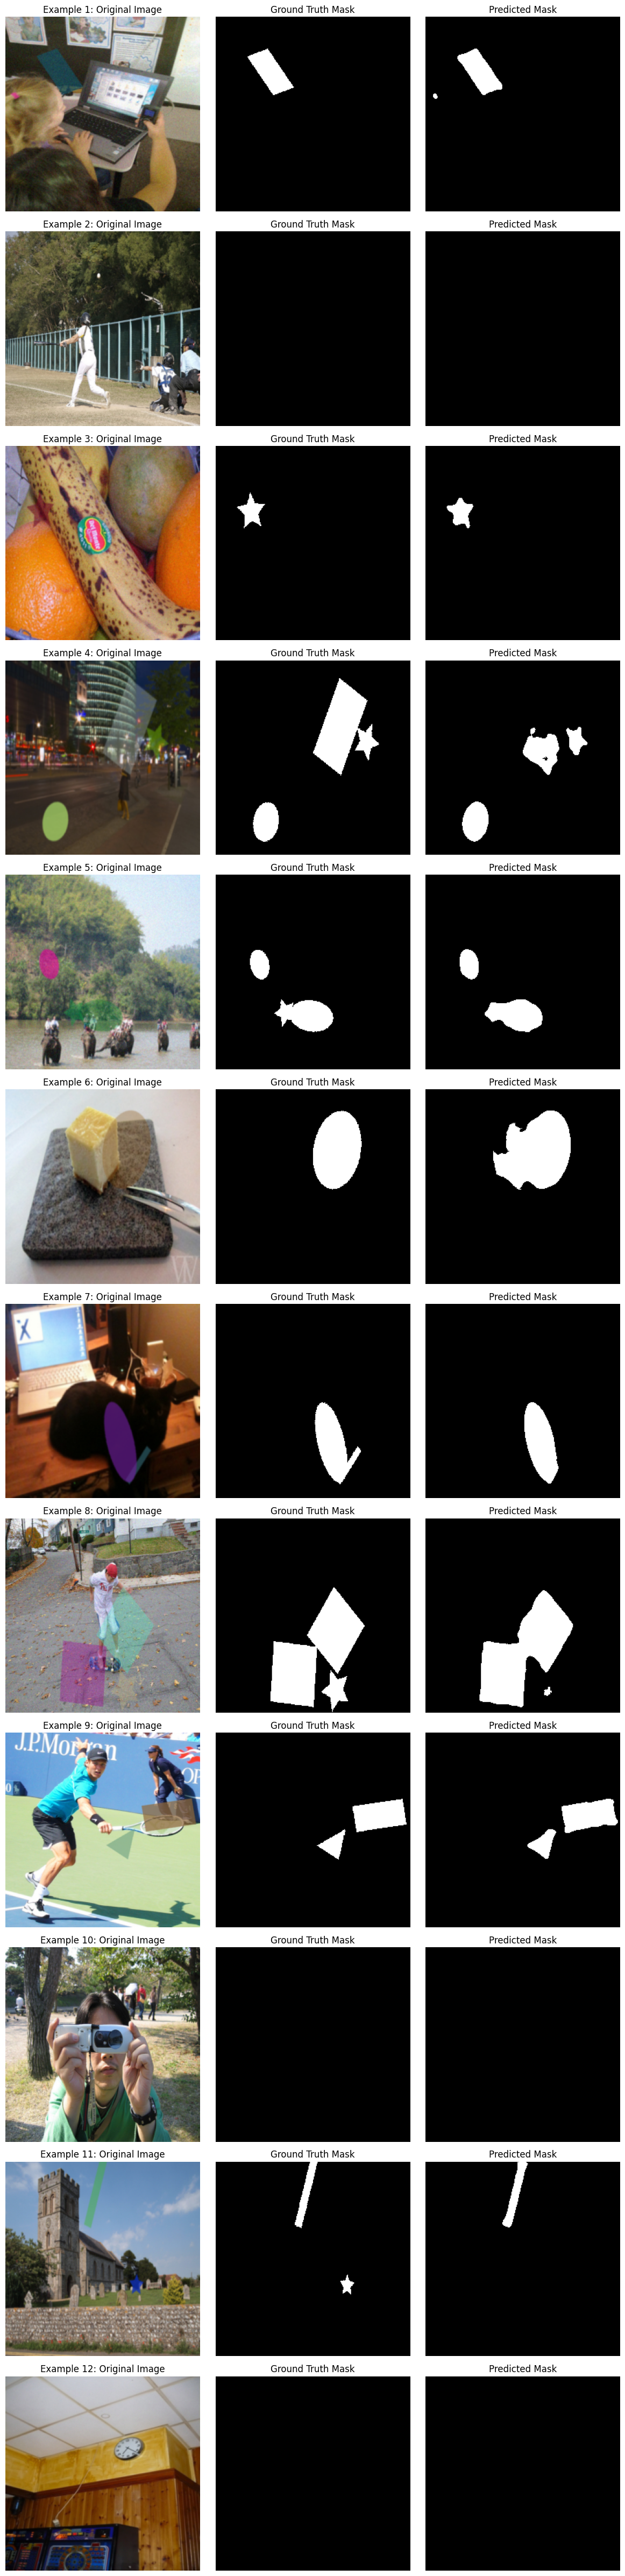

Visualizations generated! Review these to identify your successful and failure cases for the report.


In [17]:
import matplotlib.pyplot as plt
import torch
import os

# Ensure model is in evaluation mode and loaded with best weights
import os
model_path = 'best_segmentation_model.pth'
drive_model_path = '/content/drive/MyDrive/Neural_Practice_Exam/best_segmentation_model.pth'
if not os.path.exists(model_path) and os.path.exists(drive_model_path):
    print('Loading model directly from Google Drive...')
    model_path = drive_model_path
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Grab a single batch from the test loader
# BATCH_SIZE is 64, so we have enough for 12 examples
images, targets = next(iter(test_loader))
masks = targets['mask'].unsqueeze(1).float()

# Run predictions
with torch.no_grad():
    images_dev = images.to(device)
    raw_preds = model(images_dev)
    # Apply threshold > 0.0 for logits to get binary predictions (0 or 1)
    binary_preds = (raw_preds > 0.0).float().cpu()

# Prepare for plotting
num_examples_to_plot = 12
fig, axes = plt.subplots(num_examples_to_plot, 3, figsize=(12, 4 * num_examples_to_plot))

# Denormalization stats
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

for i in range(num_examples_to_plot):
    # 1. Original Image: Denormalize and convert to [H, W, C]
    img_display = images[i].cpu().permute(1, 2, 0) * std + mean
    img_np = img_display.clamp(0, 1).numpy()

    # 2. Ground Truth Mask: drop channel dim
    true_mask_np = masks[i].squeeze(0).cpu().numpy()

    # 3. Predicted Mask: drop channel dim
    pred_mask_np = binary_preds[i].squeeze(0).numpy()

    # Plot Image
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Example {i+1}: Original Image")
    axes[i, 0].axis('off')

    # Plot True Mask
    axes[i, 1].imshow(true_mask_np, cmap='gray')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

    # Plot Predicted Mask
    axes[i, 2].imshow(pred_mask_np, cmap='gray')
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis('off')

plt.tight_layout()

# Ensure directory exists and save the figure
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/test_predictions.png', bbox_inches='tight')
print("Saved figure to results/figures/test_predictions.png")

plt.show()

print("Visualizations generated! Review these to identify your successful and failure cases for the report.")

## Step 11: Ablation Experiments

In [18]:
import torch.optim as optim
import torch.nn as nn

class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss()
        self.bce_w  = bce_weight
        self.dice_w = dice_weight

    def dice_loss(self, preds, targets, eps=1e-6):
        preds   = torch.sigmoid(preds)
        inter   = (preds * targets).sum(dim=(2, 3))
        union   = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice    = (2 * inter + eps) / (union + eps)
        return 1 - dice.mean()

    def forward(self, preds, targets):
        return self.bce_w * self.bce(preds, targets) +                self.dice_w * self.dice_loss(preds, targets)

criterion = CombinedLoss()

import copy
from torch.utils.data import Subset

# Helper function to run a short experiment
def run_short_experiment(exp_model, exp_train_loader, epochs=2):
    exp_optimizer = optim.AdamW(exp_model.parameters(), lr=LEARNING_RATE)
    exp_best_iou = 0.0

    for epoch in range(epochs):
        # Train
        exp_model.train()
        for images, targets in exp_train_loader:
            images = images.to(device)
            masks = targets['mask'].to(device).unsqueeze(1).float()
            exp_optimizer.zero_grad()
            loss = criterion(exp_model(images), masks)
            loss.backward()
            exp_optimizer.step()

        # Val
        exp_model.eval()
        epoch_val_iou = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                masks = targets['mask'].to(device).unsqueeze(1).float()
                epoch_val_iou += calculate_iou(exp_model(images), masks) * images.size(0)
        epoch_val_iou /= len(val_loader.dataset)
        exp_best_iou = max(exp_best_iou, epoch_val_iou)
        print(f"  Epoch {epoch+1}/{epochs} | Val IoU: {epoch_val_iou:.4f}")

    return exp_best_iou

print("Helper function for experiments defined!")

Helper function for experiments defined!


In [19]:
import torch.optim as optim
import torch.nn as nn

class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss()
        self.bce_w  = bce_weight
        self.dice_w = dice_weight

    def dice_loss(self, preds, targets, eps=1e-6):
        preds   = torch.sigmoid(preds)
        inter   = (preds * targets).sum(dim=(2, 3))
        union   = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice    = (2 * inter + eps) / (union + eps)
        return 1 - dice.mean()

    def forward(self, preds, targets):
        return self.bce_w * self.bce(preds, targets) +                self.dice_w * self.dice_loss(preds, targets)

criterion = CombinedLoss()

import copy
from torch.utils.data import Subset

# Initialize best_val_iou and NUM_EPOCHS_OPTIMIZED to avoid NameError if Step 14 was skipped
best_val_iou = 0.8392  # From Notebook 2 Training Phase
NUM_EPOCHS_OPTIMIZED = 15 # Assuming 15 epochs for the main training loop if not explicitly defined

# Helper function to run a short experiment
def run_short_experiment(exp_model, exp_train_loader, epochs=2):
    exp_optimizer = optim.AdamW(exp_model.parameters(), lr=LEARNING_RATE)
    exp_best_iou = 0.0

    for epoch in range(epochs):
        # Train
        exp_model.train()
        for images, targets in exp_train_loader:
            images = images.to(device)
            masks = targets['mask'].to(device).unsqueeze(1).float()
            exp_optimizer.zero_grad()
            loss = criterion(exp_model(images), masks)
            loss.backward()
            exp_optimizer.step()

        # Val
        exp_model.eval()
        epoch_val_iou = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                masks = targets['mask'].to(device).unsqueeze(1).float()
                epoch_val_iou += calculate_iou(exp_model(images), masks) * images.size(0)
        epoch_val_iou /= len(val_loader.dataset)
        exp_best_iou = max(exp_best_iou, epoch_val_iou)
        print(f"  Epoch {epoch+1}/{epochs} | Val IoU: {epoch_val_iou:.4f}")

    return exp_best_iou

print("Helper function for experiments defined!")

Helper function for experiments defined!


In [20]:
print("--- Experiment 1: Pre-trained vs From Scratch ---")
# Initialize a U-Net from scratch (no ImageNet weights)
model_scratch = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None, # None means from scratch
    in_channels=3,
    classes=1,
    activation=None
).to(device)

print("Training From-Scratch Model (2 Epochs)...")
scratch_iou = run_short_experiment(model_scratch, train_loader, epochs=2)

print(f"\nResults Exp 1:")
print(f" - Pre-trained U-Net IoU: {best_val_iou:.4f}")
print(f" - From-Scratch U-Net IoU: {scratch_iou:.4f}")

--- Experiment 1: Pre-trained vs From Scratch ---
Training From-Scratch Model (2 Epochs)...
  Epoch 1/2 | Val IoU: 0.2642
  Epoch 2/2 | Val IoU: 0.3221

Results Exp 1:
 - Pre-trained U-Net IoU: 0.8392
 - From-Scratch U-Net IoU: 0.3221


In [21]:
print("--- Experiment 2: With vs Without Data Augmentation ---")
# Create a DataLoader using eval_transform (no augmentation)
train_no_aug_dataset = SyntheticShapeDataset(train_dataset, "train", transform=eval_transform)
train_no_aug_loader = DataLoader(train_no_aug_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Initialize a fresh pretrained U-Net
model_no_aug = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

print("Training without Augmentation (2 Epochs)...")
no_aug_iou = run_short_experiment(model_no_aug, train_no_aug_loader, epochs=2)

print(f"\nResults Exp 2:")
print(f" - With Augmentation U-Net IoU: {best_val_iou:.4f}")
print(f" - Without Augmentation U-Net IoU: {no_aug_iou:.4f}")

--- Experiment 2: With vs Without Data Augmentation ---
Training without Augmentation (2 Epochs)...
  Epoch 1/2 | Val IoU: 0.3694
  Epoch 2/2 | Val IoU: 0.5214

Results Exp 2:
 - With Augmentation U-Net IoU: 0.8392
 - Without Augmentation U-Net IoU: 0.5214


In [22]:
print("--- Experiment 3: Small vs Large Training Set ---")
# Create a small subset of the training data (1000 images instead of 5000)
small_train_subset = Subset(train_syn_dataset, range(1000))
small_train_loader = DataLoader(small_train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Initialize a fresh pretrained U-Net
model_small_data = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

print("Training Pretrained Model on Small Dataset (2 Epochs)...")
small_data_iou = run_short_experiment(model_small_data, small_train_loader, epochs=2)

# Note: to make the comparison perfectly fair, you'd usually compare models trained for the same number of epochs.
# Assuming your main loop ran for 5 epochs, you can note that in your report.
print(f"\nResults Exp 3:")
print(f" - Full Data U-Net IoU (5000 images): {best_val_iou:.4f}")
print(f" - Small Data U-Net IoU (1000 images): {small_data_iou:.4f}")

--- Experiment 3: Small vs Large Training Set ---
Training Pretrained Model on Small Dataset (2 Epochs)...
  Epoch 1/2 | Val IoU: 0.0712
  Epoch 2/2 | Val IoU: 0.1519

Results Exp 3:
 - Full Data U-Net IoU (5000 images): 0.8392
 - Small Data U-Net IoU (1000 images): 0.1519


## Step 12: Save Metrics to Google Drive

In [23]:
import json, os, shutil

drive_folder = '/content/drive/MyDrive/Neural_Practice_Exam'
os.makedirs(drive_folder, exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

# metrics tuple'dan dict'e çevir
iou, dice, precision, recall = metrics_tuple  # ya da metrics eğer tuple ise
metrics_dict = {
    "Test_Foreground_IoU_Jaccard": float(iou),
    "Test_Dice_Coefficient": float(dice),
    "Test_Foreground_Precision": float(precision),
    "Test_Foreground_Recall": float(recall)
}

# metrics.json kaydet
with open('results/metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)
shutil.copy('results/metrics.json', os.path.join(drive_folder, 'metrics.json'))
print('✅ metrics.json saved to Drive!')

# Görselleri Drive'a kopyala
figures_to_save = [
    'results/figures/test_predictions.png',
    'results/figures/training_history.png',
    'results/figures/generated_samples_grid.png',
]
for fig_path in figures_to_save:
    if os.path.exists(fig_path):
        shutil.copy(fig_path, os.path.join(drive_folder, os.path.basename(fig_path)))
        print(f'✅ {os.path.basename(fig_path)} saved to Drive!')
    else:
        print(f'⚠️  {fig_path} not found, skipping.')

print('\nAll done! Check your Drive folder.')


✅ metrics.json saved to Drive!
✅ test_predictions.png saved to Drive!
⚠️  results/figures/training_history.png not found, skipping.
⚠️  results/figures/generated_samples_grid.png not found, skipping.

All done! Check your Drive folder.


In [ ]:
import os, shutil
import matplotlib.pyplot as plt
import torch

drive_folder = '/content/drive/MyDrive/Neural_Practice_Exam'
os.makedirs(drive_folder, exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

model.eval()
images_batch, targets_batch = next(iter(test_loader))
masks_batch = targets_batch['mask'].float().unsqueeze(1)  # [B,1,H,W]

with torch.no_grad():
    preds_batch = torch.sigmoid(model(images_batch.to(device))).cpu()

fig, axes = plt.subplots(12, 3, figsize=(12, 48))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

for i in range(12):
    img = images_batch[i].cpu() * std + mean   # denormalize
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    mask = masks_batch[i, 0].numpy()
    pred = (preds_batch[i, 0] > 0.5).float().numpy()

    axes[i, 0].imshow(img);      axes[i, 0].set_title("Original");    axes[i, 0].axis('off')
    axes[i, 1].imshow(mask, cmap='gray'); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred, cmap='gray'); axes[i, 2].set_title("Prediction");   axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('results/figures/test_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ test_predictions.png saved!")

for fname in os.listdir('results/figures'):
    src = f'results/figures/{fname}'
    shutil.copy(src, os.path.join(drive_folder, fname))
    print(f"✅ {fname} → Drive")

print("\nAll visuals saved to Google Drive!")
